# Module 1 — From a Business Question to a Statistical Question
### Practical Statistics for Analysts @ Natural Intelligence

> **💬 The Slack message that starts our day** (and runs through the whole workshop):
>
> *"Google's converting way better than Bing this week — 45% vs 35% — mobile EPV looks down, and weekend EPV is crashing. Should we pull budget out of Bing and the weekend?"*

We *could* jump straight to tests. Instead we build the foundation first, **then** inspect the
data, **then** choose the method — because the right tool *follows* from the theory:

**Part 1 · Theory** — distributions (the *shape* of data) and the Central Limit Theorem (why
*averages* are trustworthy). → **Part 2 · Inspect the data** — the NI visit grain and its KPIs. →
**Part 3 · Choose the tool** — the right method follows from the distribution.

In [1]:
import sys
from pathlib import Path
_here = Path.cwd()
for _c in [_here, *_here.parents]:
    if (_c / "src" / "ni_style.py").exists():
        sys.path.insert(0, str(_c / "src")); break
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import ni_style as ni
ni.set_style()

visits = ni.load_visits()
print(f"Loaded {len(visits):,} visits | {visits['date'].min().date()} -> {visits['date'].max().date()}")
visits.head()

Loaded 180,000 visits | 2026-03-01 -> 2026-05-30


,visit_id,date,day_of_week,is_weekend,engine,device,vertical,converted,revenue,cost,profit
0,1,2026-03-01,Sun,True,Bing,mobile,vpn,0,0.0000,0.8094,-0.8094
1,2,2026-03-01,Sun,True,Organic,tablet,vpn,0,0.0000,0.1886,-0.1886
2,3,2026-03-01,Sun,True,Google,tablet,web_builders,0,0.0000,3.6039,-3.6039
3,4,2026-03-01,Sun,True,Google,desktop,dating,1,10.0945,1.0836,9.0109
4,5,2026-03-01,Sun,True,Google,desktop,streaming,1,5.6453,0.8228,4.8225


# Part 1 · Theoretical background

We'll *illustrate* the theory with NI's visit-level data loaded above — each row is a visit,
`revenue` is its EPV contribution (\$0 unless it converted), and `converted` is a click-out (0/1).
We formalise the grain and KPIs in **Part 2**; first, the two ideas that decide everything else:
**distributions** and the **Central Limit Theorem**.

## Distributions: the shape of your data (and why it rules everything)

A **distribution** is just *how often each value occurs* — the **shape** of your data. Before
any statistic, ask *"what shape is this?"*, because the shape decides:

- which **summary** is honest (mean vs median),
- which **test** is valid,
- whether a few **outliers** secretly run the show.

Four shapes you'll meet constantly — two textbook, two straight from NI's own data:

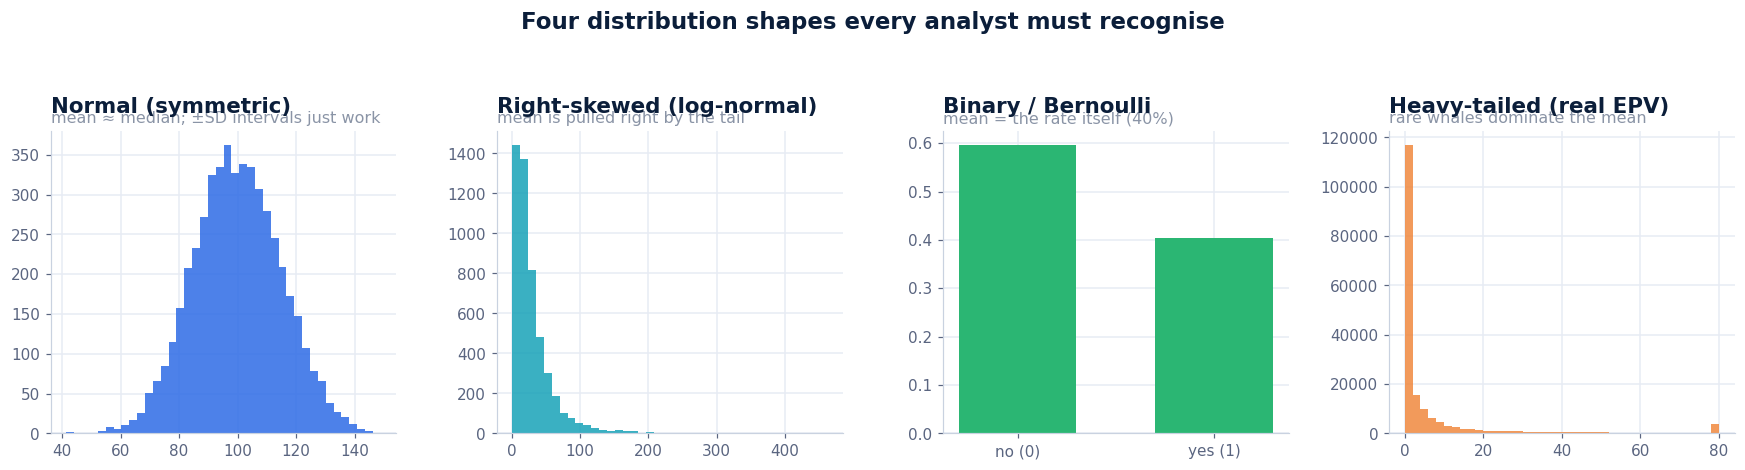

In [2]:
# A distribution = "how often each value occurs" = its SHAPE.
# We show four families: two synthetic (to see the ideal shape) + two from real NI data.
rng = np.random.default_rng(0)
fig, ax = plt.subplots(1, 4, figsize=(16, 4))

# 1) NORMAL (symmetric "bell"): values cluster around a centre; rare extremes on BOTH sides.
#    Where it shows up: measurement noise, and — crucially — AVERAGES of many things (Step 2).
normal = rng.normal(100, 15, 5000)
ax[0].hist(normal, bins=40, color=ni.BLUE, alpha=.85)
ni.titlebox(ax[0], "Normal (symmetric)", "mean ≈ median; ±SD intervals just work")

# 2) RIGHT-SKEWED / LOG-NORMAL: a wall on the left, a long tail to the right.
#    Where it shows up: session length, revenue per converting visit, prices.
skewed = rng.lognormal(3, 0.9, 5000)
ax[1].hist(skewed, bins=40, color=ni.TEAL, alpha=.85)
ni.titlebox(ax[1], "Right-skewed (log-normal)", "mean is pulled right by the tail")

# 3) BINARY / BERNOULLI: only two outcomes, 0 or 1. Its 'shape' is two bars,
#    and its MEAN is literally the rate. Where it shows up: converted yes/no.
conv = visits["converted"].values
ax[2].bar([0, 1], [np.mean(conv == 0), np.mean(conv == 1)], width=.6, color=ni.GREEN)
ax[2].set_xticks([0, 1]); ax[2].set_xticklabels(["no (0)", "yes (1)"])
ni.titlebox(ax[2], "Binary / Bernoulli", f"mean = the rate itself ({conv.mean():.0%})")

# 4) HEAVY-TAILED: like skewed but FAR more extreme — a few values dwarf the rest (whales).
#    This is NI's revenue-per-visit. The tail, not the bulk, drives the average.
rev = visits["revenue"].values
ax[3].hist(np.clip(rev, 0, 80), bins=40, color=ni.ORANGE, alpha=.85)  # clip only for display
ni.titlebox(ax[3], "Heavy-tailed (real EPV)", "rare whales dominate the mean")

fig.suptitle("Four distribution shapes every analyst must recognise",
             fontsize=15, fontweight="bold", color=ni.NAVY, y=1.06)
fig.tight_layout(); ni.savefig(fig, "m1_distribution_zoo"); plt.show()

### Why the shape matters — three consequences

1. **It picks your summary.** On a *symmetric* shape, mean ≈ median. On a *skewed/heavy* shape,
   the mean is dragged toward the tail and can misrepresent the "typical" visit.
2. **It picks your test.** Binary → proportion tests; symmetric-continuous → t-test;
   skewed/heavy → rank tests or bootstrap; a ratio → delta/bootstrap. *(That's Step 3.)*
3. **It decides whether outliers run the show.** In heavy tails the top 1% can be most of the
   total — so "the average" is really a story about a few whales.

Consequence #1 in numbers — watch the mean/median gap widen as the shape gets heavier:

In [3]:
# Diagnostic: the ratio  mean / median.
#   ~1.0  -> symmetric: the mean is a safe, honest summary.
#   >>1.0 -> right-skewed/heavy: the mean is inflated by the tail; prefer the median / be careful.
rows = []
for name, data in [("Normal (symmetric)", normal),
                   ("Right-skewed",        skewed),
                   ("Heavy-tailed EPV*",   rev[rev > 0])]:   # * converting visits only
    m, med = np.mean(data), np.median(data)
    rows.append([name, m, med, m / med])

summary = pd.DataFrame(rows, columns=["distribution", "mean", "median", "mean / median"])
display(summary.round(2))
print("Top -> bottom the shape gets heavier and mean/median climbs far above 1.0:")
print("the mean stops describing a 'typical' visit and starts describing the whales.")

,distribution,mean,median,mean / median
0,Normal (symmetric),99.93,99.59,1.00
1,Right-skewed,30.32,20.50,1.48
2,Heavy-tailed EPV*,19.37,6.32,3.06


Top -> bottom the shape gets heavier and mean/median climbs far above 1.0:
the mean stops describing a 'typical' visit and starts describing the whales.


## The Central Limit Theorem: why we can still trust averages

Shapes like EPV are ugly — so how can we ever put a clean "±1.96·SE" interval around *mean*
EPV? The **Central Limit Theorem (CLT)**: the **average** of many independent observations has a
*sampling distribution* that approaches a **normal** curve as n grows — *whatever the raw shape*
— with spread (standard error) = σ/√n.

The key idea: **the CLT acts on the *mean*, not on the raw values.** Watch the sampling
distribution of mean EPV go from badly skewed to bell-shaped as n grows:

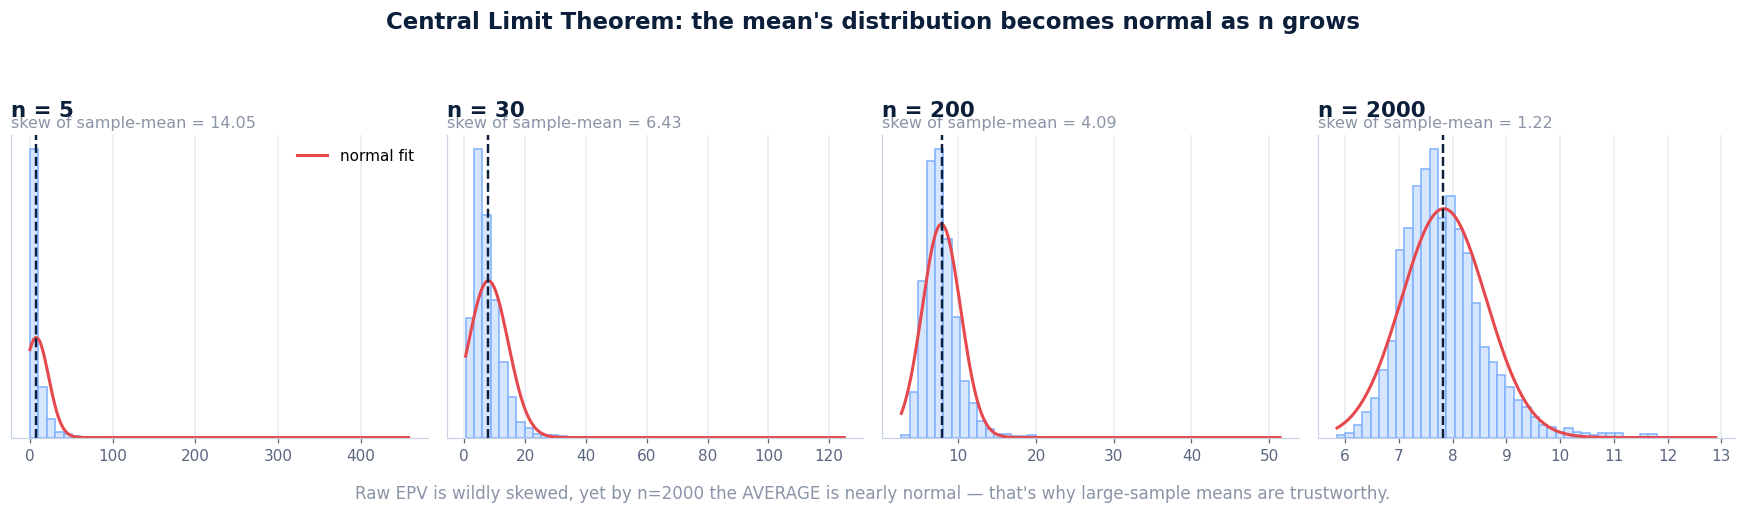

In [4]:
from scipy.stats import skew, norm
rng = np.random.default_rng(0)
pop = visits["revenue"].values            # the raw, heavy-tailed population (EPV per visit)
true_mu = pop.mean()
ns = [5, 30, 200, 2000]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, n in zip(axes, ns):
    # Draw 4000 independent samples of size n; take each sample's MEAN.
    # The histogram of those 4000 means IS the sampling distribution of the mean at this n.
    means = rng.choice(pop, size=(4000, n)).mean(axis=1)
    ax.hist(means, bins=45, density=True, color=ni.LIGHT, edgecolor=ni.SKY)
    # Overlay the normal curve the CLT predicts — the fit improves as n grows.
    xs = np.linspace(means.min(), means.max(), 200)
    ax.plot(xs, norm.pdf(xs, means.mean(), means.std()), color=ni.RED, lw=2, label="normal fit")
    ax.axvline(true_mu, color=ni.NAVY, lw=1.6, ls="--")
    ni.titlebox(ax, f"n = {n}", f"skew of sample-mean = {skew(means):.2f}")
    ax.set_yticks([])
axes[0].legend()
fig.suptitle("Central Limit Theorem: the mean's distribution becomes normal as n grows",
             fontsize=15, fontweight="bold", color=ni.NAVY, y=1.07)
fig.text(0.5, -0.04, "Raw EPV is wildly skewed, yet by n=2000 the AVERAGE is nearly normal — "
         "that's why large-sample means are trustworthy.", ha="center", color=ni.GREY, fontsize=11)
fig.tight_layout(); ni.savefig(fig, "m1_clt_in_action"); plt.show()

### The leap: the two promises that turn "it's normal" into a confidence interval

Watching the means go *normal* still isn't enough to build an interval — for that we need two
**numbers** about that distribution of means. The CLT (plus the basic algebra of averages) pins
both down:

1. **Center.** The middle of the distribution-of-means is the **true population mean μ**.
   → a single sample mean is an *unbiased* estimate of μ (it doesn't systematically run high or low).
2. **Width.** The standard deviation of the distribution-of-means is **σ/√n** — and *that quantity is
   the Standard Error (SE)*. → uncertainty shrinks like 1/√n: quadruple the data, halve the spread.

Those two numbers ARE the interval: **μ̂ ± 1.96 × (σ/√n)**.

> ℹ️ *Precise version:* the center (= μ) and width (= σ/√n) hold at **any** n — they're facts about
> averages, not the CLT. The CLT's special gift is the **normal *shape*** at large n, which is what
> lets us use the "1.96" (a normal-distribution quantile). Shape **+** center **+** width = the interval.

Let's verify the two numbers directly, by measuring the thousands of sample means themselves:

,n,centre of means,μ (true),width of means,σ/√n (predicted)
0,30,7.893,7.828,6.179,6.382
1,100,7.798,7.828,3.643,3.496
2,300,7.834,7.828,2.024,2.018
3,1000,7.830,7.828,1.108,1.105
4,3000,7.830,7.828,0.634,0.638


Promise 1 — 'centre of means' ≈ μ at every n  →  the sample mean is unbiased.
Promise 2 — 'width of means' ≈ σ/√n at every n →  that's literally why SE = σ/√n.


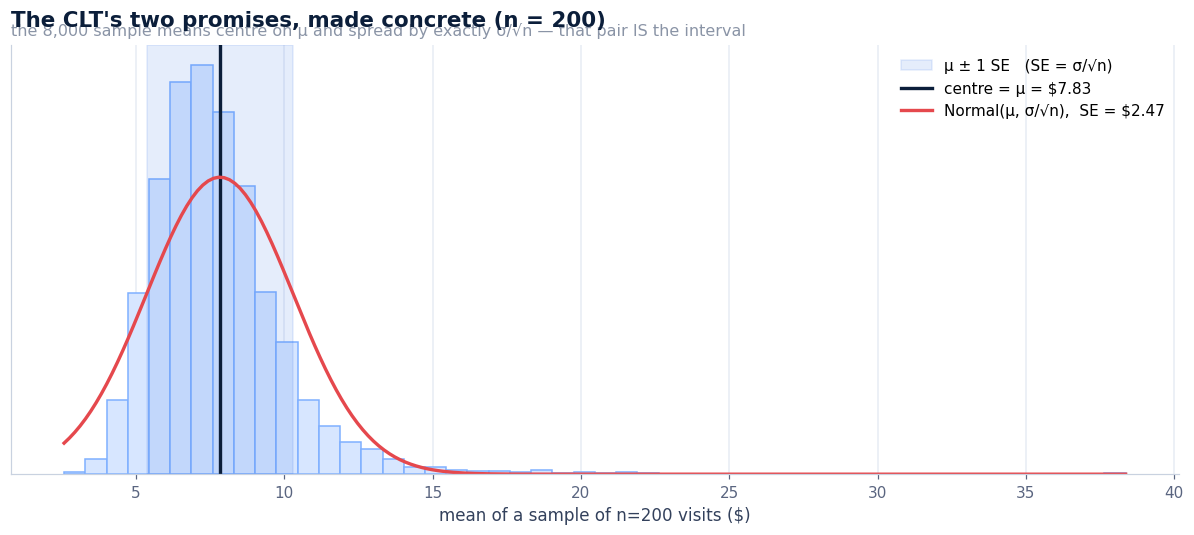

In [5]:
# We GENERATE the "distribution of many means" and then measure its CENTRE and WIDTH,
# checking each against the CLT's prediction.
from scipy.stats import norm
rng = np.random.default_rng(0)
pop = visits["revenue"].values
mu_true = pop.mean()      # the true population mean μ (known here — it's mock data)
sigma   = pop.std()       # the population standard deviation σ

# --- Promise check across several sample sizes ---
rows = []
for n in [30, 100, 300, 1000, 3000]:
    means = rng.choice(pop, size=(8000, n)).mean(axis=1)     # 8000 sample-means of size n
    rows.append([n,
                 means.mean(),          # CENTRE of the means (empirical)  -> should equal μ
                 mu_true,               # μ for comparison
                 means.std(),           # WIDTH of the means (empirical)   -> should equal σ/√n
                 sigma/np.sqrt(n)])     # σ/√n the CLT predicts
check = pd.DataFrame(rows, columns=["n", "centre of means", "μ (true)",
                                    "width of means", "σ/√n (predicted)"])
display(check.round(3))
print("Promise 1 — 'centre of means' ≈ μ at every n  →  the sample mean is unbiased.")
print("Promise 2 — 'width of means' ≈ σ/√n at every n →  that's literally why SE = σ/√n.")

# --- Visual proof at n = 200: centred on μ, spread by exactly σ/√n ---
n = 200
means = rng.choice(pop, size=(8000, n)).mean(axis=1)
se = sigma / np.sqrt(n)                                        # the Standard Error = σ/√n

fig, ax = plt.subplots(figsize=(11, 5))
ax.hist(means, bins=50, density=True, color=ni.LIGHT, edgecolor=ni.SKY)
ax.axvspan(mu_true - se, mu_true + se, color=ni.BLUE, alpha=0.12, label="μ ± 1 SE   (SE = σ/√n)")
ax.axvline(mu_true, color=ni.NAVY, lw=2.2, label=f"centre = μ = ${mu_true:.2f}")   # promise 1
xs = np.linspace(means.min(), means.max(), 200)
ax.plot(xs, norm.pdf(xs, mu_true, se), color=ni.RED, lw=2.2,                        # promise 2 (width=σ/√n)
        label=f"Normal(μ, σ/√n),  SE = ${se:.2f}")
ax.set_xlabel(f"mean of a sample of n={n} visits ($)"); ax.set_yticks([]); ax.legend()
ni.titlebox(ax, "The CLT's two promises, made concrete (n = 200)",
            "the 8,000 sample means centre on μ and spread by exactly σ/√n — that pair IS the interval")
fig.tight_layout(); ni.savefig(fig, "m1_clt_two_promises"); plt.show()

### How much data do you actually need? (the heavy-tail tax)

Promise 2 has a sharp business consequence. The mean's **relative** uncertainty is **CV / √n**, where
**CV = σ/μ** is the coefficient of variation — *how heavy the tail is relative to the average*. EPV's
CV ≈ 4.5 (σ ≈ 35 on a mean of ≈ 8), so EPV is **expensive to measure**: you need a surprising amount
of traffic before the average is pinned down. The curve below turns that into a planning rule.

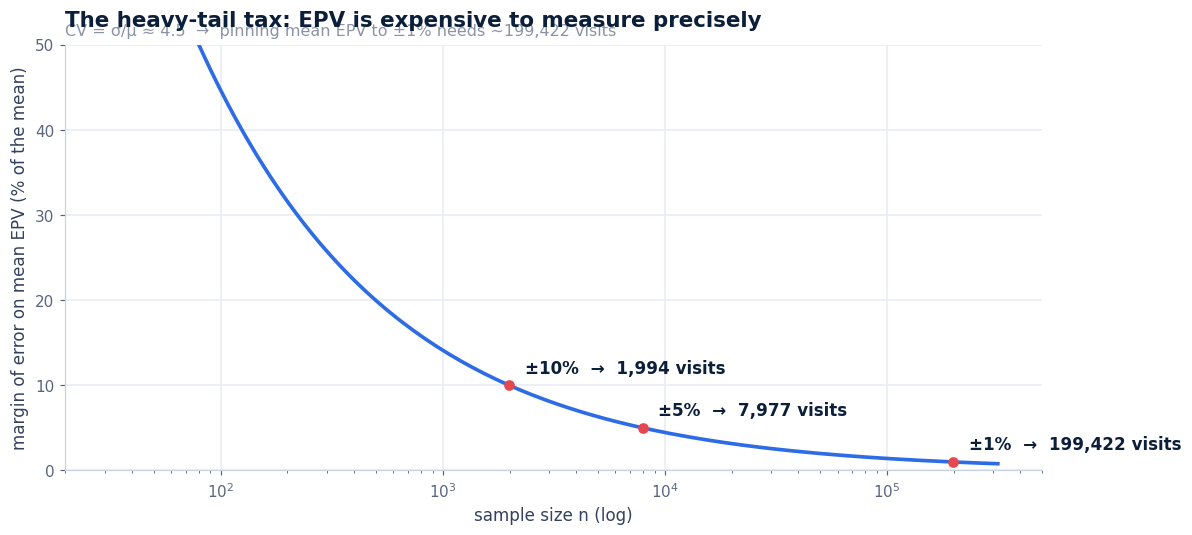

σ=35.0,  μ=7.83,  CV=4.47
  ±10% precision on mean EPV  ->  ~    1,994 visits
  ± 5% precision on mean EPV  ->  ~    7,977 visits
  ± 2% precision on mean EPV  ->  ~   49,855 visits
  ± 1% precision on mean EPV  ->  ~  199,422 visits

Rule of thumb: a tame metric (CV≈1) hits ±1% at ~10k; EPV (CV≈4.5) needs ~20x more.


In [6]:
# Relative margin of error on mean EPV = CV / sqrt(n).  Lower CV (tamer data) -> cheaper to measure.
mu, sigma = pop.mean(), pop.std()
cv = sigma / mu                                   # coefficient of variation (how heavy the tail is)
ns = np.logspace(1.5, 5.5, 150)                   # ~30 ... ~300,000 visits
rel_se = cv / np.sqrt(ns) * 100                   # margin of error as a % of the mean

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(ns, rel_se, color=ni.BLUE, lw=2.4)
for target in [10, 5, 1]:                         # how many visits to hit ±10%, ±5%, ±1%?
    n_need = (cv / (target/100))**2               # invert CV/sqrt(n) = target
    ax.scatter([n_need], [target], color=ni.RED, zorder=5)
    ax.annotate(f"±{target}%  →  {n_need:,.0f} visits", (n_need, target),
                textcoords="offset points", xytext=(10, 8), color=ni.NAVY, fontweight="bold")
ax.set_xscale("log"); ax.set_ylim(0, 50)
ax.set_xlabel("sample size n (log)"); ax.set_ylabel("margin of error on mean EPV (% of the mean)")
ni.titlebox(ax, "The heavy-tail tax: EPV is expensive to measure precisely",
            f"CV = σ/μ ≈ {cv:.1f}  →  pinning mean EPV to ±1% needs ~{(cv/0.01)**2:,.0f} visits")
fig.tight_layout(); ni.savefig(fig, "m1_data_hunger"); plt.show()

print(f"σ={sigma:.1f},  μ={mu:.2f},  CV={cv:.2f}")
for target in [10, 5, 2, 1]:
    print(f"  ±{target:>2}% precision on mean EPV  ->  ~{(cv/(target/100))**2:>9,.0f} visits")
print("\nRule of thumb: a tame metric (CV≈1) hits ±1% at ~10k; EPV (CV≈4.5) needs ~20x more.")

### CLT at work: from a skewed metric to a valid decision

We've now watched the means go normal **and** verified the CLT's two promises (centre = μ,
width = σ/√n). Time to *spend* them: two experiments turn that theory into an actual business
call — and, crucially, *check that it's allowed to*.

#### 🔬 Experiment 1 — Can a simple CLT interval drive a real decision?

**The claim being tested.** EPV is heavy-tailed, so any *single* visit is unpredictable — yet the
CLT says the *mean* of a large sample is near-normal, so we should be able to attach a trustworthy
"± margin of error" to mean EPV and act on it.

**How the experiment works.** We take the media buyer's real question — *"Is desktop EPV higher
than mobile, and by how much?"* — compute each device's mean EPV from tens of thousands of visits,
wrap each mean in a textbook CLT interval (`mean ± 1.96·SE`, where `SE = σ/√n`), then form the
**difference** of the two means and its interval.

**What proves the point.** If the CLT is doing its job, the *difference* interval will sit cleanly
away from \$0 — a margin of error tight enough to act on, produced by a one-line formula on
otherwise-ugly data.

desktop: EPV=$8.402  (n=60,927, SE=$0.136)  95% CI [$8.136, $8.667]
 mobile: EPV=$7.532  (n=104,793, SE=$0.113)  95% CI [$7.310, $7.754]

Desktop − Mobile EPV = $0.869   95% CI [$0.523, $1.216]
The interval is entirely above $0 → the gap is real → safe to act (lean bids to desktop).


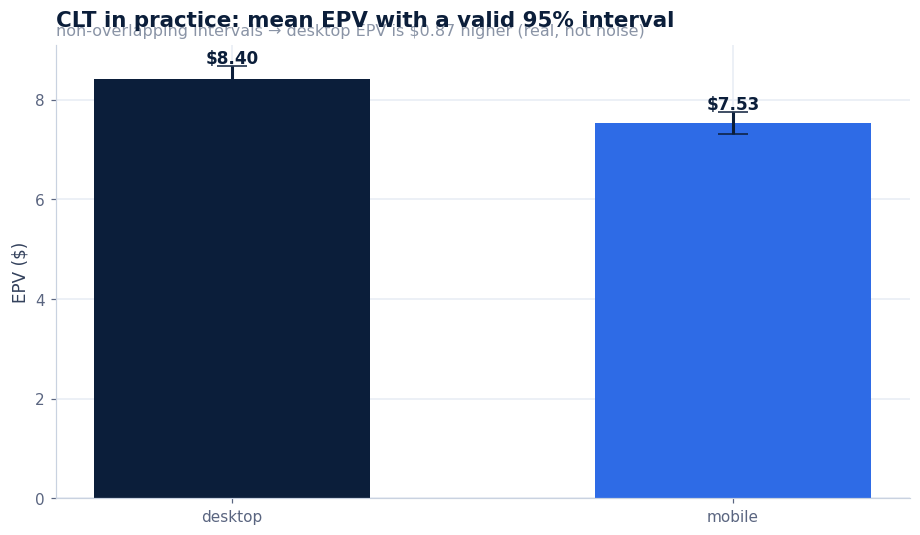

In [7]:
# --- CLT AT WORK: a real decision the media buyer needs ---
# Q: is DESKTOP EPV higher than MOBILE EPV, and by how much?
# With tens of thousands of visits per group the CLT applies, so we can use the textbook
# "mean ± 1.96 * SE" interval on the MEAN even though EPV itself is heavy-tailed.

def clt_ci(x, z=1.96):
    n = len(x); m = x.mean()
    se = x.std(ddof=1) / np.sqrt(n)          # standard error = sigma / sqrt(n)  <- straight from the CLT
    return n, m, se, m - z*se, m + z*se       # 95% interval the CLT licenses

stats_by_dev = {}
for dev in ["desktop", "mobile"]:
    n, m, se, lo, hi = clt_ci(visits.loc[visits.device == dev, "revenue"].values)
    stats_by_dev[dev] = (n, m, se, lo, hi)
    print(f"{dev:>7}: EPV=${m:.3f}  (n={n:,}, SE=${se:.3f})  95% CI [${lo:.3f}, ${hi:.3f}]")

# Difference of two INDEPENDENT means: variances add, so the SEs combine in quadrature.
(nd, md_, sed, *_), (nm, mm, sem, *_) = stats_by_dev["desktop"], stats_by_dev["mobile"]
diff = md_ - mm
se_diff = np.sqrt(sed**2 + sem**2)
dlo, dhi = diff - 1.96*se_diff, diff + 1.96*se_diff
print(f"\nDesktop − Mobile EPV = ${diff:.3f}   95% CI [${dlo:.3f}, ${dhi:.3f}]")
print("The interval is entirely above $0 → the gap is real → safe to act (lean bids to desktop).")

# Visualise the two means with their CLT-based 95% intervals
fig, ax = plt.subplots(figsize=(8.5, 5))
for i, dev in enumerate(["desktop", "mobile"]):
    n, m, se, lo, hi = stats_by_dev[dev]
    ax.bar(i, m, 0.55, color=ni.DEVICE_COLORS[dev])
    ax.errorbar(i, m, yerr=[[m-lo], [hi-m]], color=ni.NAVY, capsize=10, lw=2)   # CLT 95% CI
    ax.text(i, hi + 0.05, f"${m:.2f}", ha="center", fontweight="bold", color=ni.NAVY)
ax.set_xticks([0, 1]); ax.set_xticklabels(["desktop", "mobile"]); ax.set_ylabel("EPV ($)")
ni.titlebox(ax, "CLT in practice: mean EPV with a valid 95% interval",
            f"non-overlapping intervals → desktop EPV is ${diff:.2f} higher (real, not noise)")
fig.tight_layout(); ni.savefig(fig, "m1_clt_decision"); plt.show()

**📊 What Experiment 1 showed.** Desktop EPV ≈ \$8.40 and mobile ≈ \$7.53, and the **difference is
≈ \$0.87 with a 95% interval of about [\$0.52, \$1.22]** — entirely above \$0. The whales make
individual visits unpredictable, yet the CLT produced a precise, actionable margin of error on the
*average*. **Point proven:** large-n means are decision-ready even when the raw data is not.

---

#### 🔬 Experiment 2 — Is that CLT interval actually trustworthy at this n?

**The challenge.** The interval in Experiment 1 *assumes* the sample mean is near-normal. How do we
know that assumption has kicked in here, instead of just hoping it has?

**How the experiment works.** We re-estimate the desktop-EPV interval with the **bootstrap** — which
makes **no** distributional assumption: it rebuilds the sampling distribution empirically by
resampling the data 4,000 times and taking each resample's mean.

**What proves the point.** If the assumption-free bootstrap interval lands in the *same place* as
the CLT interval (and the bootstrap distribution sits under the CLT's predicted normal curve), then
the mean really is normal at this n — so the cheap formula is valid. If they disagreed, the CLT
interval could **not** be trusted.

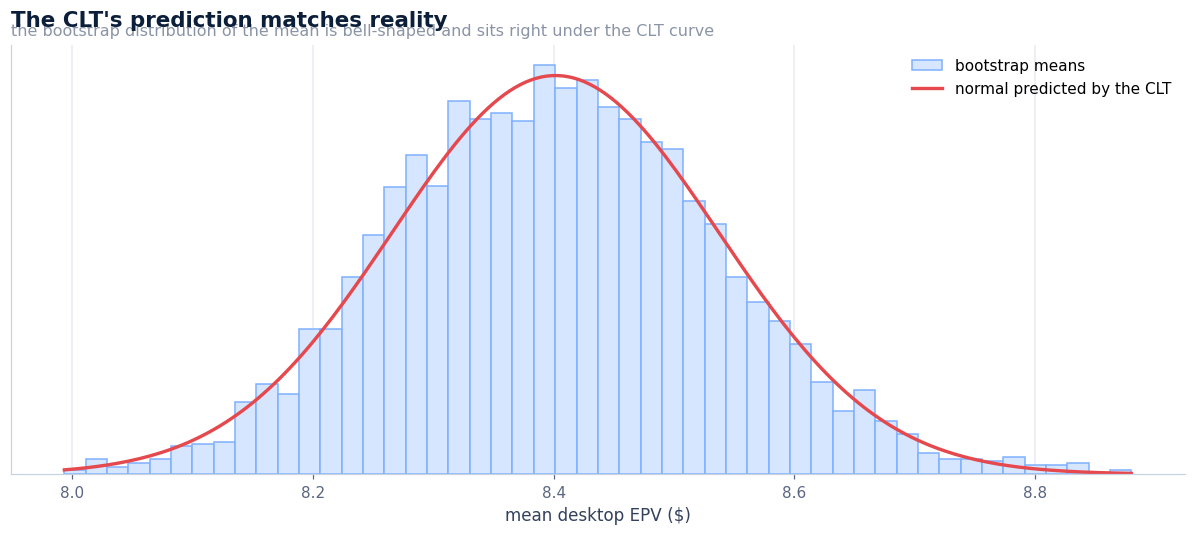

CLT       95% CI: [$8.136, $8.667]
Bootstrap 95% CI: [$8.149, $8.676]
They nearly coincide → at this n the CLT holds → the simple interval is valid,
and we can make the desktop-vs-mobile call with confidence.


In [8]:
# --- Validate the CLT interval against the assumption-free bootstrap ---
# If the two 95% CIs agree, the sample mean really is ~normal at this n (CLT holds).
from scipy.stats import norm
rng = np.random.default_rng(1)
desk = visits.loc[visits.device == "desktop", "revenue"].values

# Bootstrap: resample desktop visits WITH replacement 4000 times; record each resample's mean.
boot_means = np.array([rng.choice(desk, len(desk)).mean() for _ in range(4000)])
b_lo, b_hi = np.percentile(boot_means, [2.5, 97.5])          # bootstrap 95% CI (no normality assumed)
_, _, _, c_lo, c_hi = stats_by_dev["desktop"]                # CLT 95% CI from the previous cell

fig, ax = plt.subplots(figsize=(11, 5))
ax.hist(boot_means, bins=50, density=True, color=ni.LIGHT, edgecolor=ni.SKY, label="bootstrap means")
xs = np.linspace(boot_means.min(), boot_means.max(), 200)
ax.plot(xs, norm.pdf(xs, desk.mean(), desk.std(ddof=1)/np.sqrt(len(desk))),
        color=ni.RED, lw=2.2, label="normal predicted by the CLT")
ax.set_xlabel("mean desktop EPV ($)"); ax.set_yticks([]); ax.legend(loc="upper right")
ni.titlebox(ax, "The CLT's prediction matches reality",
            "the bootstrap distribution of the mean is bell-shaped and sits right under the CLT curve")
fig.tight_layout(); ni.savefig(fig, "m1_clt_validates"); plt.show()

print(f"CLT       95% CI: [${c_lo:.3f}, ${c_hi:.3f}]")
print(f"Bootstrap 95% CI: [${b_lo:.3f}, ${b_hi:.3f}]")
print("They nearly coincide → at this n the CLT holds → the simple interval is valid,")
print("and we can make the desktop-vs-mobile call with confidence.")

**📊 What Experiment 2 showed.** The CLT interval (≈ [\$8.14, \$8.67]) and the bootstrap interval
(≈ [\$8.15, \$8.68]) are almost identical, and the bootstrap distribution of the mean is a clean
bell sitting right under the CLT's predicted normal curve. **Point proven:** the CLT has genuinely
converged at this n — we didn't *assume* the interval was valid, we *checked* it.

> ✅ **The decision, earned validly:** desktop EPV is reliably higher than mobile (interval clear of
> \$0), and the method behind that interval is verified — so we can lean bids toward desktop with a
> one-line calculation instead of a simulation.
>
> **This is the CLT paying rent:** it converts an unpredictable, whale-ridden metric into a
> *trustworthy average with a valid margin of error* — exactly what a decision needs. The catch is
> the phrase "at this n"… which is precisely where it can go wrong (next).

### When the CLT *doesn't* save you — and what breaks

The CLT is **asymptotic**: a promise about "large enough" n. It fails to help when:

| Condition | Why it breaks | NI example |
|---|---|---|
| **n too small for the skew** | Convergence is *slow* for heavy tails — "large enough" can be thousands | one vertical × device × a single day |
| **Infinite / undefined variance** | If σ² isn't finite (extreme power-law tails) the CLT doesn't apply *at all* | a runaway whale distribution |
| **Strong dependence** | Observations aren't independent, so the *effective* n is far smaller | a bot surge or one campaign spike |

**What actually breaks:** your "95% confidence interval" stops containing the truth 95% of the
time — it **under-covers** — and your p-values are mis-calibrated. You *think* you're being
rigorous; you're quietly being overconfident. Let's *measure* it.

> **The assumption behind it all: i.i.d.** The CLT wants observations that are **i**ndependent **and
> i**dentically **d**istributed — two *separate* requirements:
> - **Identically distributed** = every observation is a draw from the *same* random variable. Pooling
>   verticals breaks this: a visit's EPV comes from the mortgages distribution (~\$65) or the dating
>   one (~\$4) depending on the row — a **mixture**, not one variable. Slicing to *one vertical × device
>   × day* is how you *buy back* "identically distributed" — but it shrinks n (row 1). You trade a
>   **mixture** problem for a **small-sample** problem.
> - **Independent** = no observation leans on another. Slicing does **not** fix this — repeat users,
>   bot bursts and campaign waves still violate it (row 3, and the demo at the end of this part).

In [9]:
# WHY pooling breaks "identically distributed": the pooled data is a MIXTURE of per-vertical
# distributions with very different centres, so its variance is inflated by the BETWEEN-vertical
# spread. Law of total variance:  Var(pooled) = E[within-vertical var] + Var[vertical means]
conv = visits[visits.converted == 1]                                   # converting visits (revenue > 0)
N = len(conv); mu_all = conv["revenue"].mean()
g_var  = conv.groupby("vertical", observed=True)["revenue"].var(ddof=0)  # spread INSIDE each vertical
g_mean = conv.groupby("vertical", observed=True)["revenue"].mean()       # the differing centres
w      = conv.groupby("vertical", observed=True).size() / N             # vertical weights

E_within = float((w * g_var).sum())                       # avg within-vertical variance
Between  = float((w * (g_mean - mu_all)**2).sum())        # variance OF the vertical means (the mixture)
pooled   = conv["revenue"].var(ddof=0)

print("Decomposing the variance of pooled revenue|converted:")
print(f"  pooled variance                  : {pooled:11,.0f}")
print(f"  = avg WITHIN-vertical variance    : {E_within:11,.0f}")
print(f"  + BETWEEN-vertical variance (mix) : {Between:11,.0f}")
print(f"\n  the BETWEEN term is {Between/pooled:.0%} of the total — pure mixture, not visit-to-visit noise.")
print(f"\nHomogeneous slices are far tighter than the pooled mixture:")
print(f"  std POOLED revenue|converted     : ${conv['revenue'].std():9,.1f}")
print(f"  std WITHIN 'dating' only         : ${conv.loc[conv.vertical=='dating','revenue'].std():9,.1f}")
print(f"  std WITHIN 'mortgages' only      : ${conv.loc[conv.vertical=='mortgages','revenue'].std():9,.1f}")
print("\n→ Conditioning on vertical removes the between-group chunk → an (almost) identically")
print("  distributed sample — at the cost of the smaller n inside each cell.")

Decomposing the variance of pooled revenue|converted:
  pooled variance                  :       2,800
  = avg WITHIN-vertical variance    :       2,365
  + BETWEEN-vertical variance (mix) :         434

  the BETWEEN term is 16% of the total — pure mixture, not visit-to-visit noise.

Homogeneous slices are far tighter than the pooled mixture:
  std POOLED revenue|converted     : $     52.9
  std WITHIN 'dating' only         : $      6.3
  std WITHIN 'mortgages' only      : $    120.9

→ Conditioning on vertical removes the between-group chunk → an (almost) identically
  distributed sample — at the cost of the smaller n inside each cell.


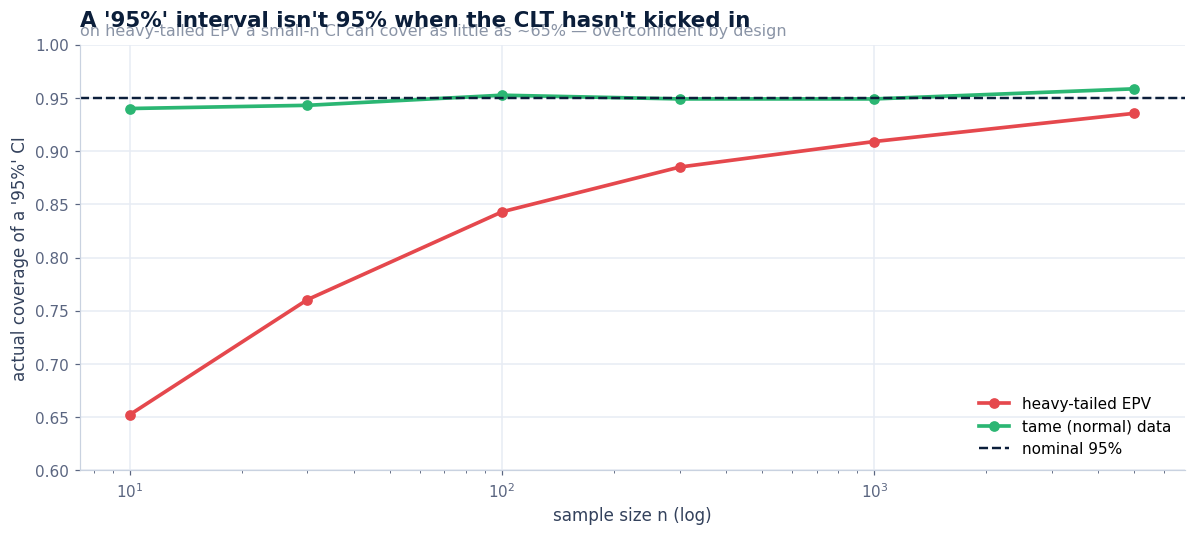

  EPV  n=  10:  a nominal-95% CI actually covers 65.2%
  EPV  n=  30:  a nominal-95% CI actually covers 76.0%
  EPV  n= 100:  a nominal-95% CI actually covers 84.3%
  EPV  n= 300:  a nominal-95% CI actually covers 88.5%
  EPV  n=1000:  a nominal-95% CI actually covers 90.9%
  EPV  n=5000:  a nominal-95% CI actually covers 93.5%


In [10]:
from scipy import stats
rng = np.random.default_rng(7)

def coverage(population, ns, reps=2000, conf=0.95):
    """Empirical coverage: of many textbook 95% t-intervals, what fraction actually contain
    the TRUE mean? If the CLT has kicked in it should be ~95%; if not, it UNDER-covers."""
    mu = population.mean(); out = []
    for n in ns:
        s = rng.choice(population, size=(reps, n))          # 'reps' fresh samples of size n
        m, sd = s.mean(axis=1), s.std(axis=1, ddof=1)       # each sample's mean and SD
        se = sd / np.sqrt(n)                                 # standard error of the mean
        tcrit = stats.t.ppf(0.5 + conf/2, n - 1)             # textbook t critical value
        lo, hi = m - tcrit*se, m + tcrit*se                  # each sample's "95%" CI
        out.append(np.mean((lo <= mu) & (mu <= hi)))         # fraction that caught the truth
    return out

ns = [10, 30, 100, 300, 1000, 5000]
cov_epv  = coverage(pop, ns)                                       # heavy-tailed EPV
tame     = rng.normal(pop.mean(), pop.std()/3, size=200_000)       # a well-behaved control group
cov_tame = coverage(tame, ns)

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(ns, cov_epv,  "-o", color=ni.RED,   lw=2.4, label="heavy-tailed EPV")
ax.plot(ns, cov_tame, "-o", color=ni.GREEN, lw=2.4, label="tame (normal) data")
ax.axhline(0.95, color=ni.NAVY, ls="--", lw=1.6, label="nominal 95%")
ax.set_xscale("log"); ax.set_ylim(0.60, 1.0)
ax.set_xlabel("sample size n (log)"); ax.set_ylabel("actual coverage of a '95%' CI"); ax.legend()
ni.titlebox(ax, "A '95%' interval isn't 95% when the CLT hasn't kicked in",
            "on heavy-tailed EPV a small-n CI can cover as little as ~65% — overconfident by design")
fig.tight_layout(); ni.savefig(fig, "m1_clt_coverage"); plt.show()

for n, c in zip(ns, cov_epv):
    print(f"  EPV  n={n:>4}:  a nominal-95% CI actually covers {c:.1%}")

> **The lesson from the breakdown:** at small n on EPV, a "95%" CI may really cover only ~65–88%
> — you'd reject true nulls and ship false findings far more often than you think. The fixes are
> exactly the branch-2/3 tools: **get more data**, use the **bootstrap** (which re-derives the
> sampling distribution empirically instead of assuming normality), or a **rank test** (which
> doesn't depend on the mean at all). This is *why* Module 2 obsesses over EPV's shape, and
> Module 5 bootstraps its intervals.

### Adtech reality check: when to distrust the CLT before betting budget

Two situations should make you suspicious of *any* `σ/√n` interval — both everywhere in adtech:

**1 · Too little data behind a slice** *(the breakdown above).* A niche vertical × device × a single
day can be a few hundred heavy-tailed visits, so the mean and its interval are unreliable and the
"95%" CI is really ~75–85%. *Decision risk:* you "spot a winner" in a thin segment and move bids on
pure noise.

**2 · The observations aren't independent** — the failure analysts miss most, because the math still
*runs*; it just lies. `σ/√n` assumes independent visits. In adtech they rarely are:

- **Intra-user correlation** — one visitor generates 10 sessions; those 10 EPVs move together, so
  they are nowhere near 10 *independent* facts (randomization unit = user, analysis unit = visit;
  Deng et al. 2018, Kohavi et al. 2020).
- **Campaign / creative bursts** — one creative or a budget spike floods you with similar traffic:
  thousands of rows, little independent information.
- **Bot / fraud surges & time-of-day waves** — correlated clumps that inflate counts without adding
  signal.
- **Ratio metrics (EPV, CTR, ROAS)** — a ratio's variance is *not* a mean's SE at all.

When observations cluster, the **true** standard error is *larger* than `σ/√n` — often several times
larger — so the naive interval is too narrow and you over-declare "significant" wins. Let's measure it
on a classic adtech pattern: many visits per user.

naive  SE (assumes 20,000 independent visits): 0.0350
true   SE (accounts for the 2,000 user clusters): 0.0891
-> real uncertainty is 2.5x larger than the naive CLT interval admits
-> a naive '95%' CI is ~2.5x too NARROW: you'd call noise a 'significant' win


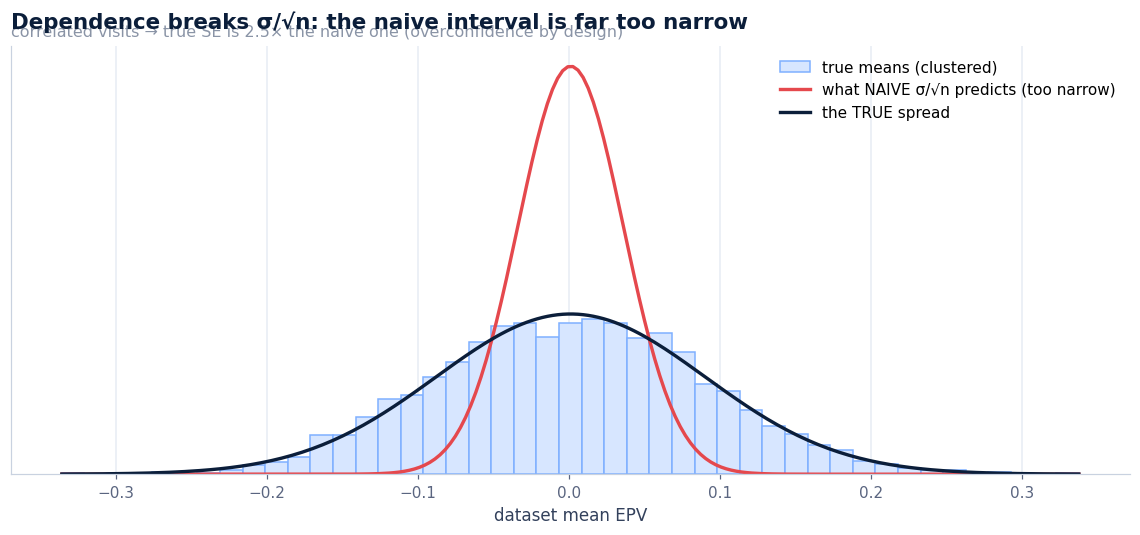

In [11]:
# Adtech CLUSTERING: 2,000 users x 10 visits each = 20,000 visits, where each user's visits
# share a user-level effect -> visits within a user are CORRELATED, not independent.
rng = np.random.default_rng(3)
n_users, k = 2000, 10

def make_clustered():
    user_effect = rng.normal(0, 4.0, n_users)        # shared by all of a user's visits (the correlation)
    noise       = rng.normal(0, 3.0, (n_users, k))   # independent visit-level noise
    return (user_effect[:, None] + noise).ravel()    # 20,000 visit-level values

# TRUE spread of the dataset mean under clustering: simulate many whole datasets, look at the means.
true_means = np.array([make_clustered().mean() for _ in range(3000)])
true_se = true_means.std()

# NAIVE SE: take ONE dataset and pretend all 20,000 visits are independent (the usual mistake).
one = make_clustered()
naive_se = one.std(ddof=1) / np.sqrt(len(one))

inflation = true_se / naive_se
print(f"naive  SE (assumes 20,000 independent visits): {naive_se:.4f}")
print(f"true   SE (accounts for the 2,000 user clusters): {true_se:.4f}")
print(f"-> real uncertainty is {inflation:.1f}x larger than the naive CLT interval admits")
print(f"-> a naive '95%' CI is ~{inflation:.1f}x too NARROW: you'd call noise a 'significant' win")

from scipy.stats import norm
fig, ax = plt.subplots(figsize=(10.5, 5))
ax.hist(true_means, bins=45, density=True, color=ni.LIGHT, edgecolor=ni.SKY, label="true means (clustered)")
xs = np.linspace(true_means.min(), true_means.max(), 200)
ax.plot(xs, norm.pdf(xs, true_means.mean(), naive_se), color=ni.RED, lw=2.2,
        label="what NAIVE σ/√n predicts (too narrow)")
ax.plot(xs, norm.pdf(xs, true_means.mean(), true_se), color=ni.NAVY, lw=2.2, label="the TRUE spread")
ax.set_yticks([]); ax.set_xlabel("dataset mean EPV"); ax.legend()
ni.titlebox(ax, "Dependence breaks σ/√n: the naive interval is far too narrow",
            f"correlated visits → true SE is {inflation:.1f}× the naive one (overconfidence by design)")
fig.tight_layout(); ni.savefig(fig, "m1_clustering"); plt.show()

### Taking the wrong decision on dependent data — an A/B test that ships noise

The inflated SE isn't academic — it flips real decisions. Here's the classic adtech mistake: we A/B
test a new landing page **B** against control **A** on EPV. **In truth B does nothing** (A and B are
identical). But visits cluster by user, and we analyse at the **visit** level with a t-test that
assumes every visit is independent. Repeat this *null* experiment 1,000 times and ask how often each
method falsely declares a winner — a correct test should be fooled only ~5% of the time (that's α).

False-positive rate over 1,000 NULL A/B tests (truth: A and B identical):
  NAIVE visit-level t-test :   38%    <- should be 5%
  CORRECT user-level t-test:    5%    <- ~5%, as intended

→ the naive test cries 'significant winner!' about 8x too often.


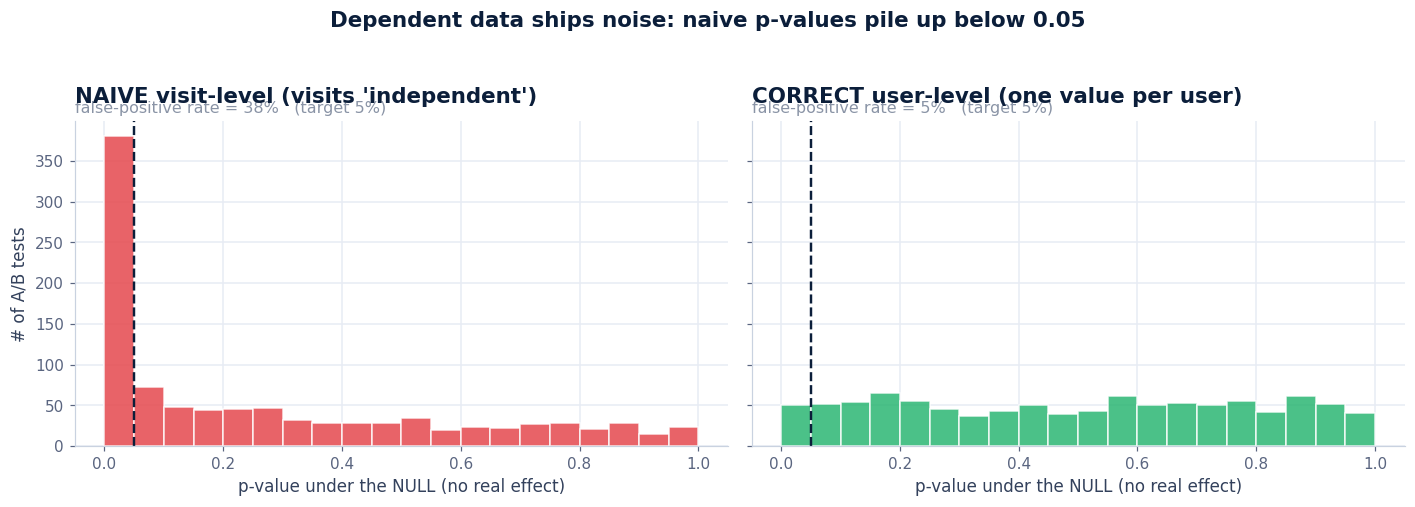

In [12]:
from scipy import stats
rng = np.random.default_rng(20)
n_users, k = 300, 20                        # users are the randomization unit; k visits each, per arm

def one_null_experiment():
    # NULL world: A and B identical. Each user's k visits share a user effect -> correlated (dependent).
    def arm():
        u = rng.normal(0, 2.0, n_users)                          # user-level effect = the dependence
        return u[:, None] + rng.normal(0, 4.0, (n_users, k))     # (users x visits), pure normal noise
    A, B = arm(), arm()
    p_naive = stats.ttest_ind(A.ravel(), B.ravel(), equal_var=False).pvalue   # WRONG: visits 'independent'
    p_user  = stats.ttest_ind(A.mean(1),  B.mean(1),  equal_var=False).pvalue # RIGHT: one value per user
    return p_naive, p_user

res = np.array([one_null_experiment() for _ in range(1000)])
fp_naive = (res[:, 0] < 0.05).mean()
fp_user  = (res[:, 1] < 0.05).mean()
print("False-positive rate over 1,000 NULL A/B tests (truth: A and B identical):")
print(f"  NAIVE visit-level t-test : {fp_naive:5.0%}    <- should be 5%")
print(f"  CORRECT user-level t-test: {fp_user:5.0%}    <- ~5%, as intended")
print(f"\n→ the naive test cries 'significant winner!' about {fp_naive/0.05:.0f}x too often.")

fig, ax = plt.subplots(1, 2, figsize=(13, 4.4), sharey=True)
for a, col, title, fp, color in [
        (ax[0], 0, "NAIVE visit-level (visits 'independent')", fp_naive, ni.RED),
        (ax[1], 1, "CORRECT user-level (one value per user)",  fp_user,  ni.GREEN)]:
    a.hist(res[:, col], bins=20, range=(0, 1), color=color, alpha=.85, edgecolor="white")
    a.axvline(0.05, color=ni.NAVY, ls="--", lw=1.6)
    ni.titlebox(a, title, f"false-positive rate = {fp:.0%}   (target 5%)")
    a.set_xlabel("p-value under the NULL (no real effect)")
ax[0].set_ylabel("# of A/B tests")
fig.suptitle("Dependent data ships noise: naive p-values pile up below 0.05",
             fontsize=14, fontweight="bold", color=ni.NAVY, y=1.04)
fig.tight_layout(); ni.savefig(fig, "m1_dependence_decision"); plt.show()

> **The wrong decision, concretely:** on dependent data the naive visit-level test declares a "winner"
> far more than 5% of the time — so you'd routinely report *"landing page B lifts EPV, p<0.05 — ship it
> and shift budget,"* when **B does nothing**. The maths was fine; the *inputs weren't independent*. The
> correct user-level test stays at ~5%, as it should.

> **What this means for the business:** that dataset has 20,000 rows, but because the visits cluster
> into 2,000 users it carries the *information* of far fewer independent observations. Trust the naive
> `σ/√n` interval and you'd announce a "statistically significant" lift and reallocate budget — when
> the true uncertainty is ~2–3× wider and the "win" is noise.
>
> **Be suspicious whenever:** the slice is thin; a few users / campaigns / creatives dominate the rows;
> traffic arrived in bursts; or the metric is a ratio (EPV, CTR, ROAS). **The fixes:** resample or
> cluster by **user** (not visit), use the **delta method** for ratio metrics (Module 5), or collect
> more *independent* units — **more users, not more visits from the same users.**

> 🧭 **CLT trust checklist** — before acting on a `mean ± 1.96·SE` interval, confirm: (a) enough data
> behind *this* slice; (b) observations are roughly independent (no user/campaign/bot clustering);
> (c) finite variance / not a raw ratio. Fail any one → use the bootstrap or delta method instead.

# Part 2 · Inspecting the NI data

We've used EPV and conversions to *illustrate* the theory. Now, before picking tools, let's lay out
the actual table we'll analyse — the **grain** and the **KPIs** computed from it.

## One row per **visit**

Dimensions describe each visit; `converted` / `revenue` / `cost` are its outcomes. The KPIs are just
**averages over this grain**: `conversion_rate = mean(converted)` and `EPV = mean(revenue)`.

In [13]:
# Each row is ONE visit. Dimensions describe it; converted/revenue/cost are the outcomes.
print("Grain check — one row per visit:")
display(visits[["date", "engine", "device", "vertical", "converted", "revenue", "cost"]].head())

# The two headline KPIs are just column averages over the grain:
#   conversion_rate = mean of the 0/1 'converted' column  -> a PROPORTION
#   EPV             = mean of the 'revenue' column         -> a heavy-tailed MEAN
print("\nHeadline metrics, computed from the grain:")
print(f"  overall conversion rate : {visits['converted'].mean():.1%}")
print(f"  overall EPV             : ${visits['revenue'].mean():.2f}")
print(f"  overall CPV             : ${visits['cost'].mean():.2f}")
print(f"  profit / visit          : ${visits['profit'].mean():.2f}")

Grain check — one row per visit:


,date,engine,device,vertical,converted,revenue,cost
0,2026-03-01,Bing,mobile,vpn,0,0.0000,0.8094
1,2026-03-01,Organic,tablet,vpn,0,0.0000,0.1886
2,2026-03-01,Google,tablet,web_builders,0,0.0000,3.6039
3,2026-03-01,Google,desktop,dating,1,10.0945,1.0836
4,2026-03-01,Google,desktop,streaming,1,5.6453,0.8228



Headline metrics, computed from the grain:
  overall conversion rate : 40.4%
  overall EPV             : $7.83
  overall CPV             : $4.09
  profit / visit          : $3.74


# Part 3 · Choosing the tool: it *follows* from the distribution

Now the payoff. Because the distribution fixes the **variance structure**, it fixes the right
method. Route any request with three questions:

1. **What is the unit?** (here: a visit)
2. **What *type* is the outcome?** binary (proportion) · continuous-skewed (mean) ·
   category × category (association) · a ratio
3. **What am I comparing or relating?** two groups · a trend · a relationship

The same NI dataset wears three statistical "faces" — each needs a different tool:

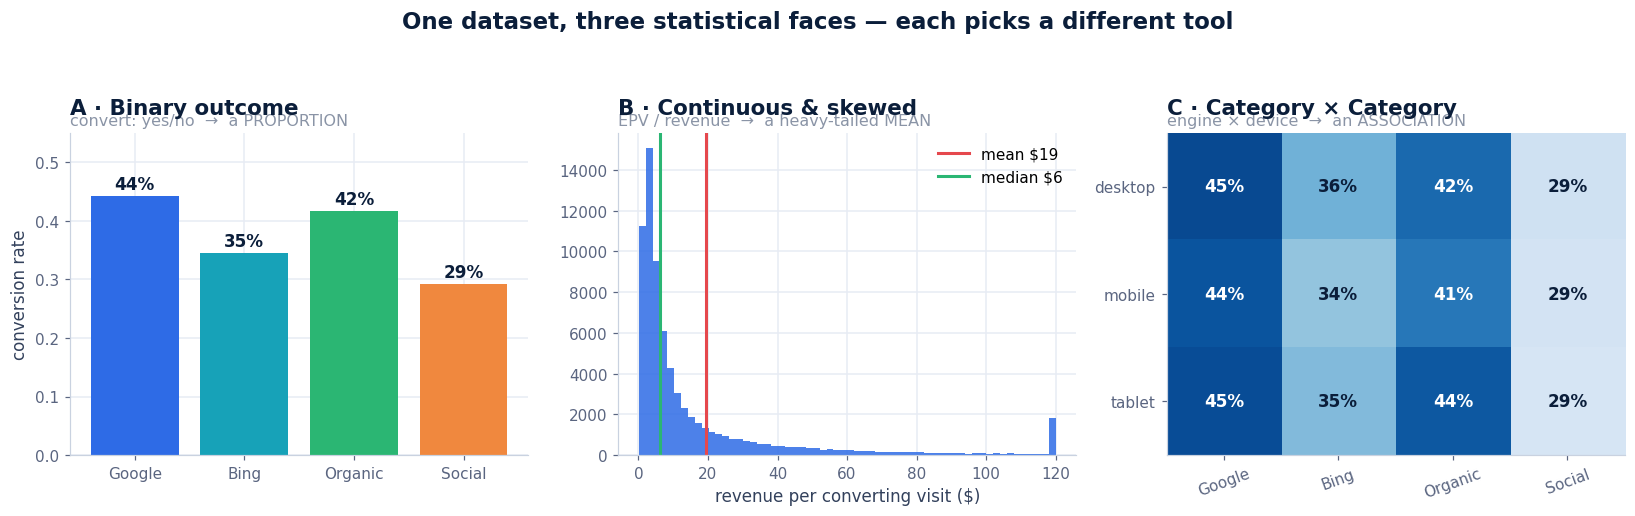

In [14]:
# The SAME data, shown as the three outcome TYPES that drive tool choice.
fig, ax = plt.subplots(1, 3, figsize=(15, 4.4))

# (A) BINARY outcome -> a PROPORTION (conversion rate by engine)
cr = visits.groupby("engine", observed=True)["converted"].mean().reindex(["Google","Bing","Organic","Social"])
ax[0].bar(cr.index, cr.values, color=[ni.ENGINE_COLORS[e] for e in cr.index])
ax[0].set_ylim(0, 0.55); ax[0].set_ylabel("conversion rate")
for i, v in enumerate(cr.values):
    ax[0].text(i, v + 0.012, f"{v:.0%}", ha="center", fontweight="bold", color=ni.NAVY)
ni.titlebox(ax[0], "A · Binary outcome", "convert: yes/no  →  a PROPORTION")

# (B) CONTINUOUS skewed outcome -> a heavy-tailed MEAN (EPV / revenue)
rev = visits.loc[visits.converted == 1, "revenue"]
ax[1].hist(rev.clip(upper=120), bins=60, color=ni.BLUE, alpha=0.85)
ax[1].axvline(rev.mean(), color=ni.RED, lw=2, label=f"mean ${rev.mean():.0f}")
ax[1].axvline(rev.median(), color=ni.GREEN, lw=2, label=f"median ${rev.median():.0f}")
ax[1].set_xlabel("revenue per converting visit ($)"); ax[1].legend()
ni.titlebox(ax[1], "B · Continuous & skewed", "EPV / revenue  →  a heavy-tailed MEAN")

# (C) CATEGORY x CATEGORY -> an ASSOCIATION (engine x device conversion grid)
piv = visits.pivot_table(index="device", columns="engine", values="converted", aggfunc="mean")
piv = piv.reindex(index=["desktop","mobile","tablet"], columns=["Google","Bing","Organic","Social"])
im = ax[2].imshow(piv.values, cmap="Blues", aspect="auto", vmin=0.25, vmax=0.47)
ax[2].set_xticks(range(4)); ax[2].set_xticklabels(piv.columns, rotation=20)
ax[2].set_yticks(range(3)); ax[2].set_yticklabels(piv.index)
for r in range(piv.shape[0]):
    for c in range(piv.shape[1]):
        ax[2].text(c, r, f"{piv.values[r,c]:.0%}", ha="center", va="center",
                   color="white" if piv.values[r,c] > 0.4 else ni.NAVY, fontweight="bold")
ax[2].grid(False)
ni.titlebox(ax[2], "C · Category × Category", "engine × device  →  an ASSOCIATION")

fig.suptitle("One dataset, three statistical faces — each picks a different tool", fontsize=15,
             fontweight="bold", color=ni.NAVY, x=0.5, y=1.06)
fig.tight_layout(); ni.savefig(fig, "m1_variable_types"); plt.show()

### The tool-selection decision tree

Pin this to your monitor. Start at the top with *"what type is my outcome?"*

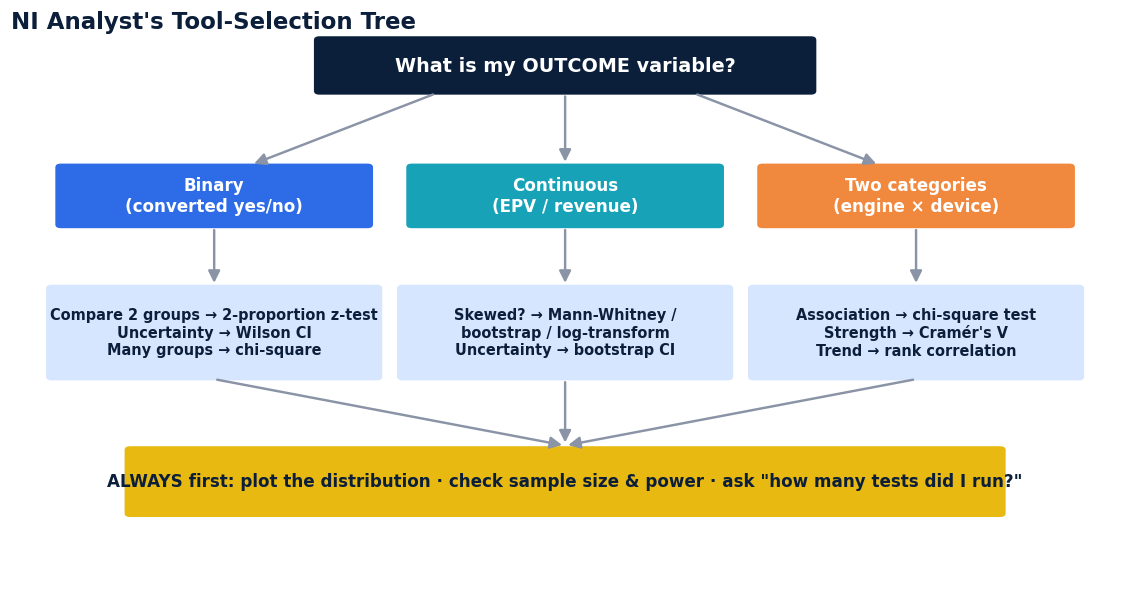

In [15]:
# This cell just DRAWS the flowchart (boxes + arrows) — no statistics here.
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

def box(ax, xy, w, h, text, fc, tc="white", fs=11):
    x, y = xy
    ax.add_patch(FancyBboxPatch((x-w/2, y-h/2), w, h, boxstyle="round,pad=0.02,rounding_size=0.06",
                                linewidth=0, facecolor=fc))
    ax.text(x, y, text, ha="center", va="center", color=tc, fontsize=fs, fontweight="bold", wrap=True)

def arrow(ax, p0, p1, label=None):
    ax.add_patch(FancyArrowPatch(p0, p1, arrowstyle="-|>", mutation_scale=16,
                                 lw=1.6, color=ni.GREY, shrinkA=2, shrinkB=2))
    if label:
        ax.text((p0[0]+p1[0])/2, (p0[1]+p1[1])/2 + 0.015, label, ha="center",
                fontsize=9.5, color=ni.NAVY, style="italic")

fig, ax = plt.subplots(figsize=(13, 6.6)); ax.set_xlim(0, 12); ax.set_ylim(0, 9); ax.axis("off")

box(ax, (6, 8.3), 5.4, 0.9, "What is my OUTCOME variable?", ni.NAVY, fs=12.5)
box(ax, (2.2, 6.2), 3.4, 1.0, "Binary\n(converted yes/no)", ni.BLUE)
box(ax, (6, 6.2), 3.4, 1.0, "Continuous\n(EPV / revenue)", ni.TEAL)
box(ax, (9.8, 6.2), 3.4, 1.0, "Two categories\n(engine × device)", ni.ORANGE)
arrow(ax, (4.6, 7.85), (2.6, 6.7))
arrow(ax, (6, 7.85), (6, 6.7))
arrow(ax, (7.4, 7.85), (9.4, 6.7))

box(ax, (2.2, 4.0), 3.6, 1.5,
    "Compare 2 groups → 2-proportion z-test\nUncertainty → Wilson CI\nMany groups → chi-square", ni.LIGHT, tc=ni.NAVY, fs=9.5)
arrow(ax, (2.2, 5.7), (2.2, 4.75))
box(ax, (6, 4.0), 3.6, 1.5,
    "Skewed? → Mann-Whitney /\nbootstrap / log-transform\nUncertainty → bootstrap CI", ni.LIGHT, tc=ni.NAVY, fs=9.5)
arrow(ax, (6, 5.7), (6, 4.75))
box(ax, (9.8, 4.0), 3.6, 1.5,
    "Association → chi-square test\nStrength → Cramér's V\nTrend → rank correlation", ni.LIGHT, tc=ni.NAVY, fs=9.5)
arrow(ax, (9.8, 5.7), (9.8, 4.75))

box(ax, (6, 1.6), 9.5, 1.1,
    "ALWAYS first: plot the distribution · check sample size & power · ask \"how many tests did I run?\"",
    ni.GOLD, tc=ni.NAVY, fs=11)
for x0 in (2.2, 6, 9.8):
    arrow(ax, (x0, 3.25), (x0 if x0==6 else 6, 2.18))

ax.text(0, 8.9, "NI Analyst's Tool-Selection Tree", fontsize=15, fontweight="bold", color=ni.NAVY)
ni.savefig(fig, "m1_decision_tree"); plt.show()

### Routing the five workshop use cases

Every use case from the syllabus maps cleanly onto the tree:

In [16]:
# Map each real NI question -> its outcome TYPE -> the right tool -> the module that covers it.
mapping = pd.DataFrame([
    ["Google vs Bing conversion (45% vs 35%)", "Binary proportion", "2-proportion z-test + Wilson CI", "Module 4 & 5"],
    ["EPV vs day-of-week", "Continuous (skewed) + trend", "Spearman correlation (+ control for mix)", "Module 3"],
    ["Outliers / whales distorting EPV", "Continuous, heavy-tailed", "Distribution + median/transform", "Module 2"],
    ["Mobile vs desktop EPV gap", "Continuous ratio", "Bootstrap CI for the ratio", "Module 5"],
    ["Mobile EPV CI [-20%, -5%]", "Interval estimate", "Confidence interval (communication)", "Module 5"],
    ["Should we move budget? (all of it)", "Decision", "End-to-end workflow", "Module 6"],
], columns=["NI use case", "Variable type", "Right tool", "Covered in"])

mapping.style.hide(axis="index").set_caption(
    "From business question → statistical tool").set_properties(**{"text-align":"left"})

NI use case,Variable type,Right tool,Covered in
Google vs Bing conversion (45% vs 35%),Binary proportion,2-proportion z-test + Wilson CI,Module 4 & 5
EPV vs day-of-week,Continuous (skewed) + trend,Spearman correlation (+ control for mix),Module 3
Outliers / whales distorting EPV,"Continuous, heavy-tailed",Distribution + median/transform,Module 2
Mobile vs desktop EPV gap,Continuous ratio,Bootstrap CI for the ratio,Module 5
"Mobile EPV CI [-20%, -5%]",Interval estimate,Confidence interval (communication),Module 5
Should we move budget? (all of it),Decision,End-to-end workflow,Module 6


## A worked guide: business decision → tool → *why that tool*

The table is the index; here is the *reasoning* — for each real NI decision, the tool to reach for
and **why it beats the obvious alternative.**

**1 · "Bing's clicks are cheaper — shift budget from Google to Bing?"**
→ testable sub-question: *do the engines convert at different rates?*
- **Outcome:** binary (converted 0/1) = a proportion. **Tool:** two-proportion **z-test + Wilson CI**.
- **Why:** a 0/1 outcome's variance is *fixed by its mean* (p(1−p)), so it needs a proportion test, not a
  t-test (which assumes a free-floating continuous spread). Wilson over the textbook Wald interval
  because Wald mis-covers. *Caveat:* conversion rate alone never decides budget — pair it with #5.

**2 · "Is mobile EPV really lower than desktop — trim mobile bids?"**
- **Outcome:** continuous, heavy-tailed (EPV). **Tool:** **Welch's t-test** on the means (n huge → CLT
  valid), *confirmed* with **Mann–Whitney** and a **bootstrap**.
- **Why:** you're comparing *means of a continuous metric*, so a proportion test doesn't apply. Welch
  (not Student's) because the groups' variances differ. You confirm with the rank test + bootstrap
  because whales make you distrust the mean's normality on any single slice — if all three agree, act.

**3 · "By *how much* is mobile EPV down — enough to matter?"**
- **Outcome:** a **ratio** (EPV = revenue ÷ visits); you want a magnitude **+ interval**. **Tool:**
  **bootstrap CI for the ratio** (or the **delta method**).
- **Why:** a ratio of random quantities has *no* plain mean's standard error, so naive ±1.96·SE is the
  wrong width. And an *interval* — not a p-value — is what tells you the effect is big enough to act on.

**4 · "Does EPV swing by day of week — bid differently on weekends?"**
- **Outcome:** a relationship on skewed data, at risk of a confound. **Tool:** **Spearman correlation**,
  then **condition on vertical**.
- **Why:** Spearman (rank) over Pearson because whales + non-linearity wreck Pearson. And you control
  for vertical because the raw "day effect" is a traffic-**mix** confound (Module 3) — tool *plus* design.

**5 · "So — do we move the budget at all?"** *(the decision that actually matters)*
- **Outcome:** **profit per visit** (= EPV − CPV) per segment, with uncertainty. **Tool:** per-segment
  **profit/visit with bootstrap CIs**; act only where the interval clears your threshold.
- **Why:** budget follows *profit*, not conversion rate or EPV alone; the **interval**, not the point,
  sets the decision rule (Module 6).

**6 · "The A/B test says the new page wins — ship it?"** *(dependence!)*
- **Outcome:** a mean comparison on data **clustered by user**. **Tool:** test at the **randomization
  unit** (one value per user), or a **cluster bootstrap** / **delta method** — *never* a visit-level t-test.
- **Why:** visits within a user are dependent, so a visit-level test underestimates variance and fires
  false winners ~8× too often (we measured it). *Pick which:* user-level t-test when you can aggregate
  cleanly; cluster bootstrap when the metric is a ratio or the aggregation is messy.

**7 · "We sliced 40 segments and 3 look significant — real?"**
- **Tool:** a **multiple-comparison correction** (Benjamini–Hochberg FDR, or Bonferroni if few tests).
- **Why:** 40 null tests at α=0.05 expect ~2 false hits; correction stops you chasing noise (Module 4).

**8 · "Before launch, how much traffic to detect a 2% EPV lift?"**
- **Tool:** a **power / sample-size calculation** (done *before* the test).
- **Why:** so you're neither underpowered (missing real effects) nor tempted to peek (inflating false
  positives). Recall the heavy-tail tax: small effects on EPV need a lot of traffic.

> **The pattern:** binary→proportion test · continuous→mean test (rank/bootstrap if skewed or thin) ·
> ratio→bootstrap/delta · relationship→rank correlation · dependent→cluster/unit-level · many tests→
> correct · and *every* decision ends on an **interval on profit-per-visit**, not a bare p-value.

## Why these tools? The reasoning — and the evidence

Tool choice isn't taste; it follows from the **variance structure** of the outcome, which is
itself fixed by the variable's *measurement scale* (Stevens 1946). Each branch of the tree
above has a documented justification:

- **Binary outcome → proportion methods.** A 0/1 mean *is* a proportion; its variance is
  p(1−p), set by the mean. Use the two-proportion z-test / chi-square, and the **Wilson**
  interval — the textbook **Wald** interval has famously erratic coverage (Brown, Cai &
  DasGupta 2001).
- **Continuous outcome → means via the CLT, but watch the shape.** In *large* samples a
  mean-based t-test is valid for *any* distribution (Lumley et al. 2002) — skew alone is not a
  reason to abandon it. The reasons to switch to **rank tests** (Mann-Whitney 1947 / Wilcoxon
  1945) or the **bootstrap** (Efron 1979) are *small slices* and *whales that destroy power*,
  not validity.
- **Ratio metric (EPV) → delta method / bootstrap.** EPV is ΣRevenue/ΣVisits — a ratio of
  random quantities whose variance is NOT a mean's standard error (Deng et al. 2018; Kohavi,
  Tang & Xu 2020).
- **Relationship → rank correlation.** Pearson is linear and outlier-sensitive; Spearman
  (1904) / Kendall (1938) use ranks and resist whales.
- **Always:** correct for **multiple comparisons** (Benjamini & Hochberg 1995) and check
  **power** (Cohen 1988).

📚 **Sources** — Stevens (1946) *Science* 103:677–680 · Brown, Cai & DasGupta (2001)
*Statistical Science* 16:101–133 · Lumley et al. (2002) *Annu. Rev. Public Health* 23:151–169 ·
Mann & Whitney (1947) *Ann. Math. Stat.* 18:50–60 · Wilcoxon (1945) *Biometrics Bull.* 1:80–83 ·
Efron (1979) *Ann. Stat.* 7:1–26 · Deng, Knoblich & Lu (2018) *KDD* (arXiv:1803.06336) ·
Kohavi, Tang & Xu (2020) *Trustworthy Online Controlled Experiments*, Cambridge ·
Spearman (1904) *Am. J. Psychol.* 15:72–101 · Kendall (1938) *Biometrika* 30:81–93 ·
Benjamini & Hochberg (1995) *JRSS-B* 57:289–300 · Cohen (1988) *Statistical Power Analysis*, 2nd ed.

### ✅ Takeaway

> **Shape first, then theory, then tool.**
> 1. Identify the **distribution** (Part 1) — it tells you whether the mean is even trustworthy.
> 2. Lean on the **CLT** (Part 1) — big-n averages are reliable; small-n heavy-tailed ones are not.
> 3. Pick the **tool from the variable type** (Part 3), not from habit.
>
> The Slack question is secretly **two** questions — a *proportion* comparison (Google vs Bing)
> and a *ratio* comparison (mobile vs desktop EPV) — answered across the next five modules.

**Next:** zoom into EPV's shape and the whales that make its mean lie. → *Module 2.*